# PC. 08)

Considere o conjunto de dados do satélite Landsat, disponível em:

[https://archive.ics.uci.edu/dataset/146/statlog+landsat+satellite](https://archive.ics.uci.edu/dataset/146/statlog+landsat+satellite)

Neste exercício, o objetivo é classificar o pixel central de recortes 3x3 de imagens do satélite Landsat. O conjunto de dados possui as seguintes classes:

 - Solo vermelho;
 - cultivo de algodão;
 - solo cinza;
 - solo cinza úmido;
 - solo com restolho vegetal;
 - solo cinza muito úmido;

Para fins didáticos, iremos simplificar o problema. Seu objetivo será realizar a classificação de SOLO VERMELHO. Sendo assim, você deve apenas diferenciar a classe de interesse das demais, modificando o problema para ser uma classificação binária. Desenvolva um modelo baseado em RNAs fully connected para realizar essa classificação. Primeiramente, realize uma análise exploratória dos dados para entender o problema.

Considerando as boas práticas no desenvolvimento de modelos, incluindo o uso de técnicas de validação cruzada, realize uma análise crítica da metodologia proposta. Analise a quantidade de classes distintas no conjunto de dados, bem como a distribuição de exemplos por classe. Com base nessa análise, escolha e justifique a estratégia de separação dos folds (estratificada ou não estratificada), discutindo os possíveis impactos dessa escolha no desempenho e na avaliação do modelo.

Para avaliar o modelo final, apresente as seguintes métricas: acurácia, precisão, recall e medida-F. Apresente também a matriz de confusão do modelo. Realize uma discussão detalhada sobre os resultados, destacando os pontos fortes do seu modelo, bem como pontos a serem melhorados. Apresente alternativas para trabalhos futuros.

## Recuperação dos dados:

In [34]:
# !pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
statlog_landsat_satellite = fetch_ucirepo(id=146) 

# data (as pandas dataframes) 
X = statlog_landsat_satellite.data.features 
y = statlog_landsat_satellite.data.targets 

# metadata 
print(statlog_landsat_satellite.metadata) 

# variable information 
print(statlog_landsat_satellite.variables.head)

{'uci_id': 146, 'name': 'Statlog (Landsat Satellite)', 'repository_url': 'https://archive.ics.uci.edu/dataset/146/statlog+landsat+satellite', 'data_url': 'https://archive.ics.uci.edu/static/public/146/data.csv', 'abstract': 'Multi-spectral values of pixels in 3x3 neighbourhoods in a satellite image, and the classification associated with the central pixel in each neighbourhood', 'area': 'Climate and Environment', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 6435, 'num_features': 36, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C55887', 'creators': ['Ashwin Srinivasan'], 'intro_paper': None, 'additional_info': {'summary': "The database consists of the multi-spectral values of pixels in 3x3 neighbourhoods in a satellite image, and the classification as

## Análise exploratória

In [35]:
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kfold import Kfold
from mlp_kfold import FFNeuralNetwork, Layer, Neuron

In [36]:
def getAllClasses():
    return pd.DataFrame({
        "class_name": [
            "Solo vermelho", "Cultivo de algodão", "Solo cinza", "Solo cinza úmido",
            "Solo com restolho vegetal", "Mixture class (all types present)", "Solo cinza muito úmido"
        ],
        "index": [1, 2, 3, 4, 5, 6, 7],
        "color": ["#FF7D66", "#5480FF", "#BDBDBD", "#698891", "#487D5D", "#AB5B96", "#45A2BF"]
    })

def getClass(index):
    classes = getAllClasses()
    result = classes[index == classes["index"]]
    result = result.reset_index(drop = True)
    return result

classes = np.unique(y)

getAllClasses()

,class_name,index,color
0,Solo vermelho,1,#FF7D66
1,Cultivo de algodão,2,#5480FF
2,Solo cinza,3,#BDBDBD
3,Solo cinza úmido,4,#698891
4,Solo com restolho vegetal,5,#487D5D
5,Mixture class (all types present),6,#AB5B96
6,Solo cinza muito úmido,7,#45A2BF


In [37]:
X.columns = [str(attr) for attr in range(1, 37)]
xy = y.join(X)
xy[:5]

,class,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,3,92,115,120,94,84,102,106,79,84,...,134,104,88,121,128,100,84,107,113,87
1,3,84,102,106,79,84,102,102,83,80,...,128,100,84,107,113,87,84,99,104,79
2,3,84,102,102,83,80,102,102,79,84,...,113,87,84,99,104,79,84,99,104,79
3,3,80,102,102,79,84,94,102,79,80,...,104,79,84,99,104,79,84,103,104,79
4,3,84,94,102,79,80,94,98,76,80,...,104,79,84,103,104,79,79,107,109,87


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled)
X_scaled.columns = [str(attr) for attr in range(1, 37)]
xy_scaled = y.join(X_scaled)
xy_scaled[:5]

,class,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,3,1.661177,1.372574,1.244208,0.603682,1.095101,0.819608,0.413457,-0.184648,1.120130,...,2.094080,1.123729,1.412427,1.656979,1.729516,0.912814,1.139685,1.058116,0.843046,0.235904
1,3,1.073150,0.804404,0.403097,-0.190128,1.095101,0.819608,0.173402,0.026552,0.823164,...,1.732879,0.913090,1.115947,1.044165,0.831474,0.230119,1.139685,0.707472,0.303936,-0.183981
2,3,1.073150,0.804404,0.162779,0.021555,0.800119,0.819608,0.173402,-0.184648,1.120130,...,0.829875,0.228512,1.115947,0.693985,0.292649,-0.190001,1.139685,0.707472,0.303936,-0.183981
3,3,0.779136,0.804404,0.162779,-0.190128,1.095101,0.470029,0.173402,-0.184648,0.823164,...,0.288073,-0.192767,1.115947,0.693985,0.292649,-0.190001,1.139685,0.882794,0.303936,-0.183981
4,3,1.073150,0.454761,0.162779,-0.190128,0.800119,0.470029,-0.066654,-0.343047,0.823164,...,0.288073,-0.192767,1.115947,0.869075,0.292649,-0.190001,0.766566,1.058116,0.603442,0.235904


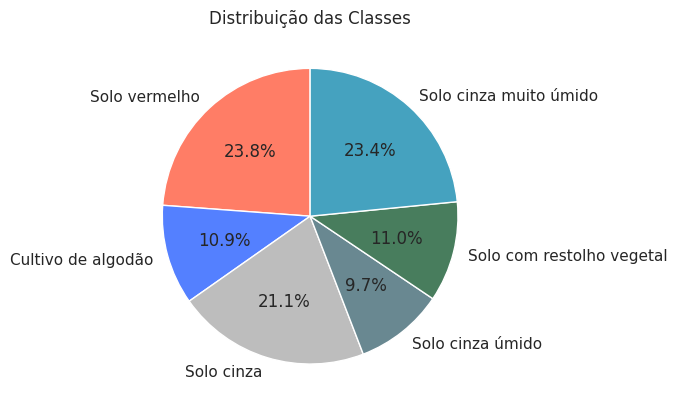

In [41]:
# Contar amostras por classe
class_counts = pd.Series(list(y['class'])).value_counts().sort_index()

# Labels (nomes das classes)
labels = [ str(getClass(index)['class_name'][0]) for index in list(set(y['class'])) ]

colors = [ str(getClass(index)['color'][0]) for index in list(set(y['class'])) ]

# Plotar gráfico de pizza
plt.figure()
plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição das Classes')

plt.show()

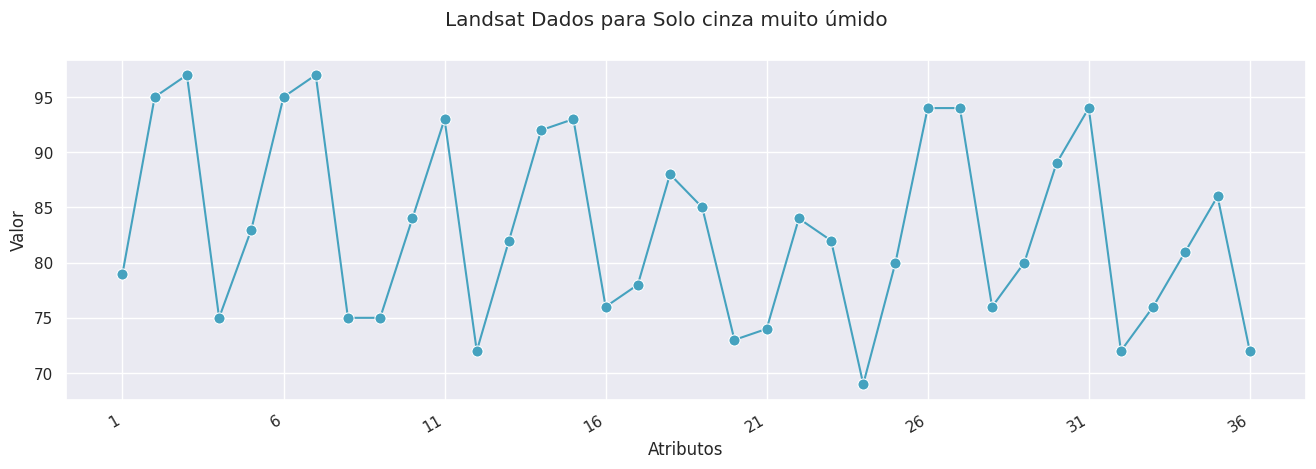

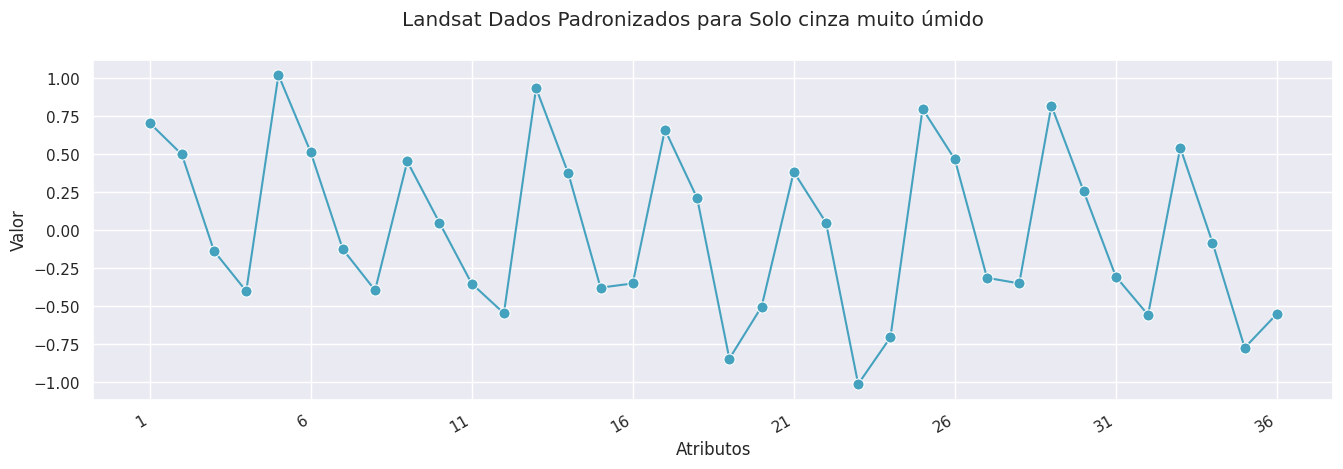

In [60]:
def plot_attr(X, y, line, scaled = False):

    X_sel = X.iloc[line]
    class_ = getClass(int(y.iloc[line]['class']))
    class_name = class_['class_name'][0]
    class_color = class_['color'][0]

    standard_ = " Padronizados" if scaled else ""
    
    fig = plt.figure(figsize = (16, 5))
    fig.suptitle(f"Landsat Dados{standard_} para {class_name}")
    
    seaborn.set_theme(style="darkgrid")
    
    seaborn.lineplot(
        x = X_sel.index,
        y = X_sel,
        markersize = 8, marker = 'o',
        linestyle = '-', picker = 10,
        color = class_color
    )
    fig.autofmt_xdate()
    plt.xticks(np.arange(0, 36, step=5)) 
    plt.xlabel('Atributos')
    plt.ylabel('Valor')
    plt.show()

line = random.randint(0, len(y))
plot_attr(X, y, line)
plot_attr(X_scaled, y, line, True)

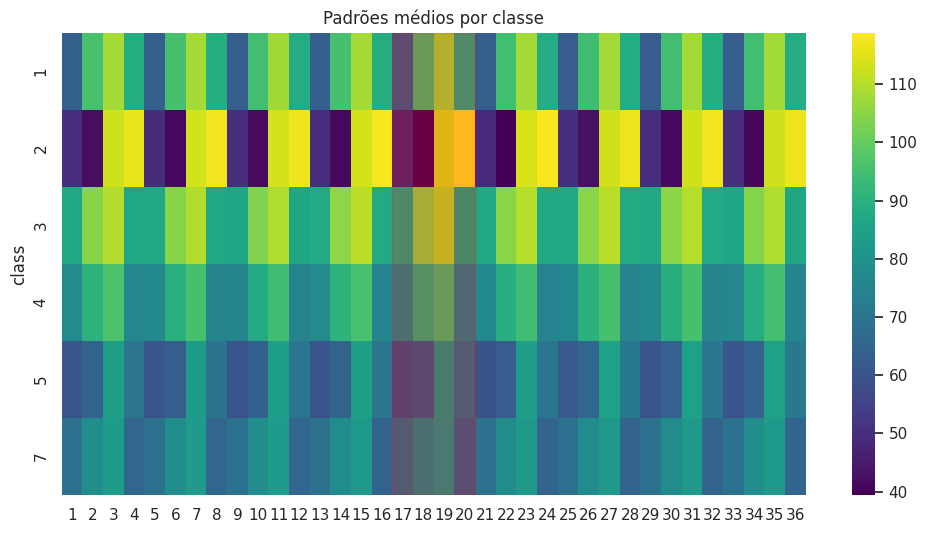

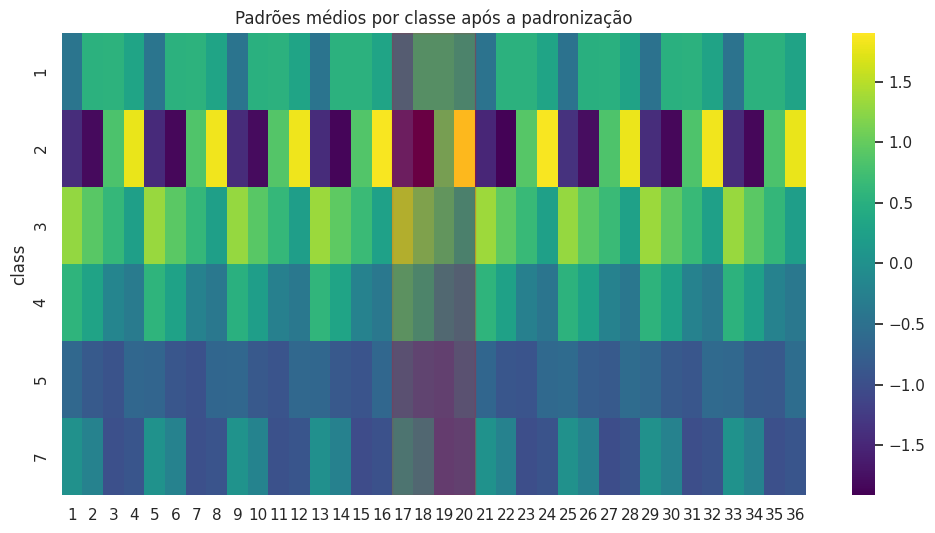

In [82]:
padroes = xy.groupby('class').mean()

plt.figure(figsize=(12,6))
seaborn.heatmap(padroes, cmap='viridis')
plt.title("Padrões médios por classe")
plt.axvspan(16, 20, color='red', alpha=0.2, label='Pixel central')
plt.show()

padroes = xy_scaled.groupby('class').mean()

plt.figure(figsize=(12,6))
seaborn.heatmap(padroes, cmap='viridis')
plt.title("Padrões médios por classe após a padronização")
plt.axvspan(16, 20, color='red', alpha=0.2, label='Pixel central')
plt.show()

In [86]:
xy_scaled.loc[xy_scaled['class'] == 1]

,class,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
2045,1,-0.470422,-0.288232,-0.798491,-0.772255,-0.158573,0.033056,-0.366724,-0.395847,0.154990,...,0.408473,0.017872,0.522987,1.219255,1.250560,0.597724,0.542695,1.408759,1.262354,1.023191
2046,1,-0.176408,0.017706,-0.377935,-0.401811,0.136409,0.338937,0.113388,0.026552,0.451956,...,1.251277,0.597131,0.522987,1.394344,1.250560,1.017844,0.244200,1.408759,1.262354,1.023191
2047,1,0.411619,0.673288,0.343017,0.180317,0.431391,0.863305,0.653513,0.184951,0.154990,...,1.251277,1.018409,0.226507,1.394344,1.549907,0.807784,0.244200,1.408759,1.262354,0.813248
2090,1,-0.690932,-0.200821,-0.618253,-0.931017,-0.453555,0.033056,-0.606780,-0.501447,-0.141976,...,0.047271,-0.087447,0.152387,0.869075,1.130821,0.702754,0.542695,1.452590,1.382156,0.865733
2091,1,-0.176408,0.585877,0.102700,-0.137207,0.357646,0.819608,0.893569,0.396151,0.377715,...,1.371677,0.860430,0.522987,1.263027,1.729516,0.860299,0.841190,1.452590,1.741562,1.075676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6427,1,0.485122,1.241458,1.364366,0.868286,0.800119,1.038094,1.373681,0.712950,0.526198,...,0.769675,0.702450,0.671227,0.912848,0.771604,0.702754,0.393447,0.006185,0.543541,0.340876
6428,1,0.779136,1.022931,1.364366,0.709524,0.505137,1.038094,1.133625,0.712950,1.120130,...,0.769675,0.702450,0.374747,-0.006374,0.532126,0.335149,-0.203542,-0.519781,0.064332,0.130933
6429,1,1.073150,1.416280,1.724843,1.079968,1.685065,1.431370,2.033834,1.082548,1.120130,...,0.047271,0.123192,0.374747,-0.006374,0.292649,0.492694,0.691942,0.575981,0.783145,0.708276
6430,1,-0.690932,-0.025999,-0.197697,0.127396,-0.379810,0.164148,0.053374,0.290551,-0.364701,...,0.288073,0.491811,-0.218213,0.168716,0.532126,0.335149,-0.427414,0.006185,0.303936,0.130933


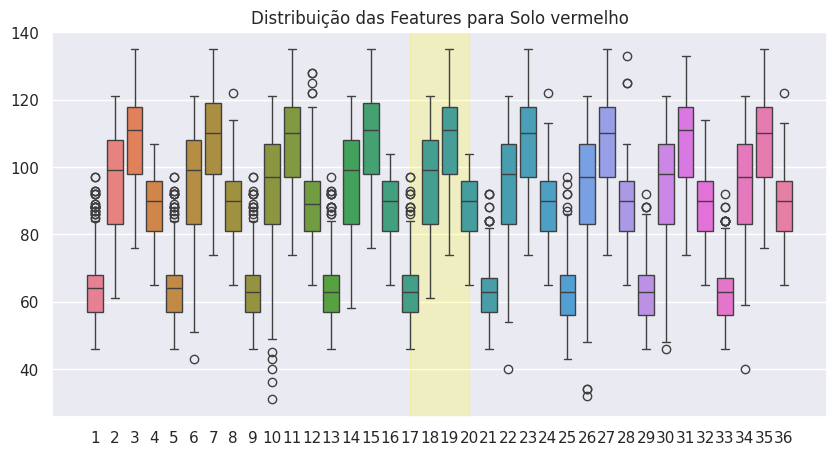

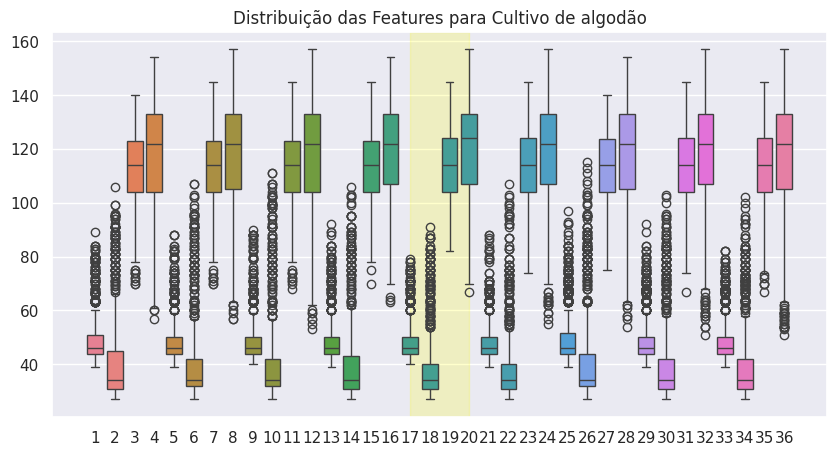

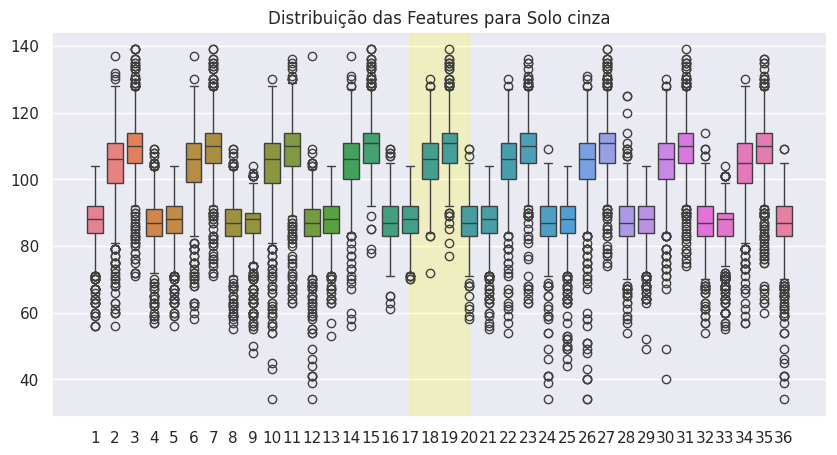

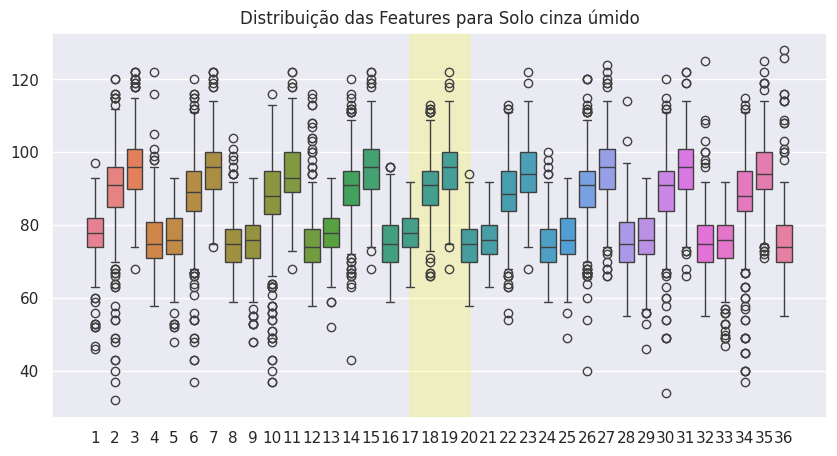

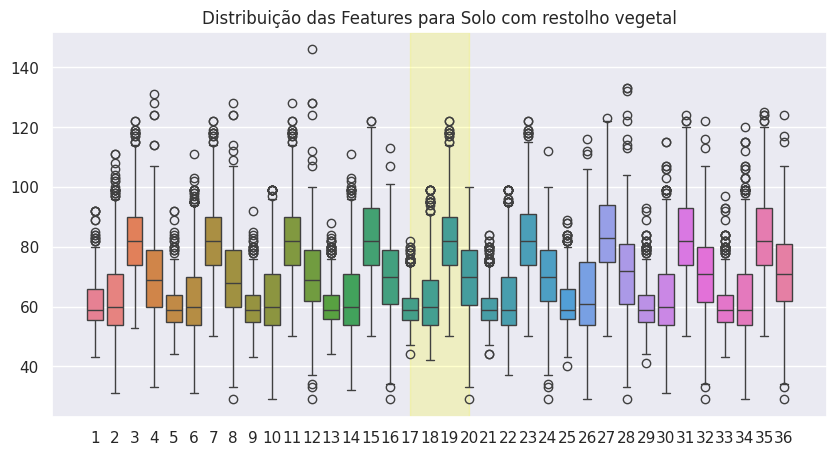

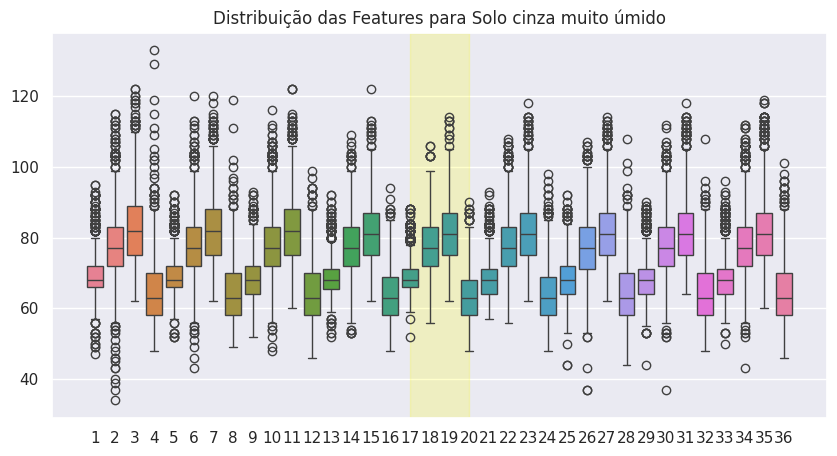

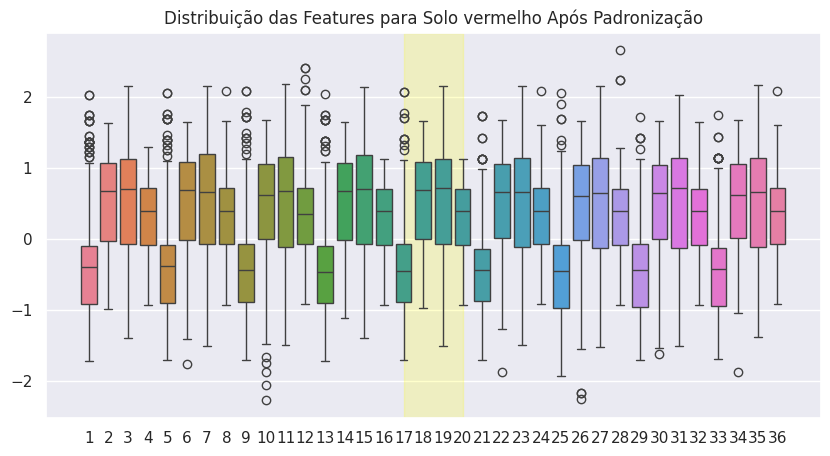

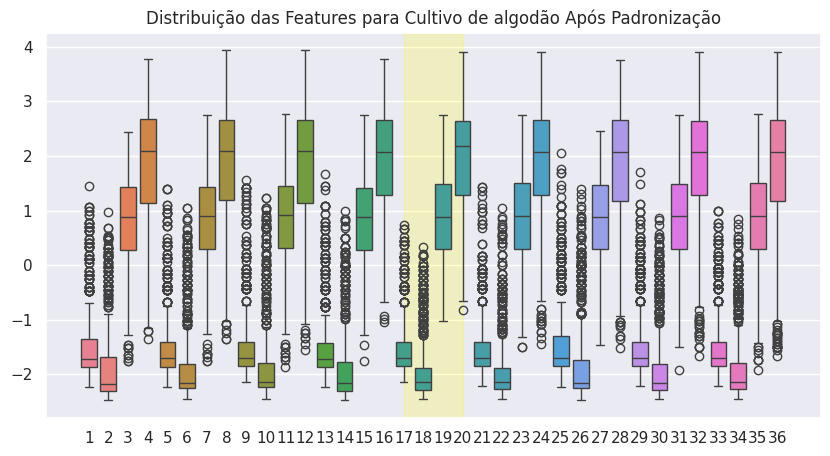

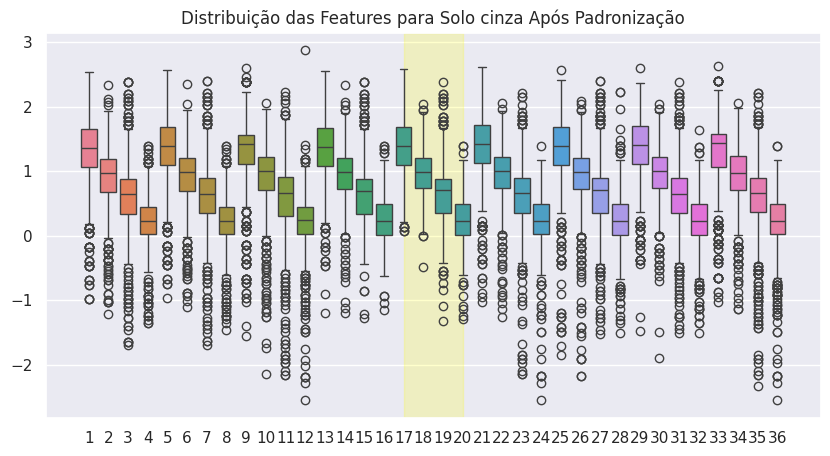

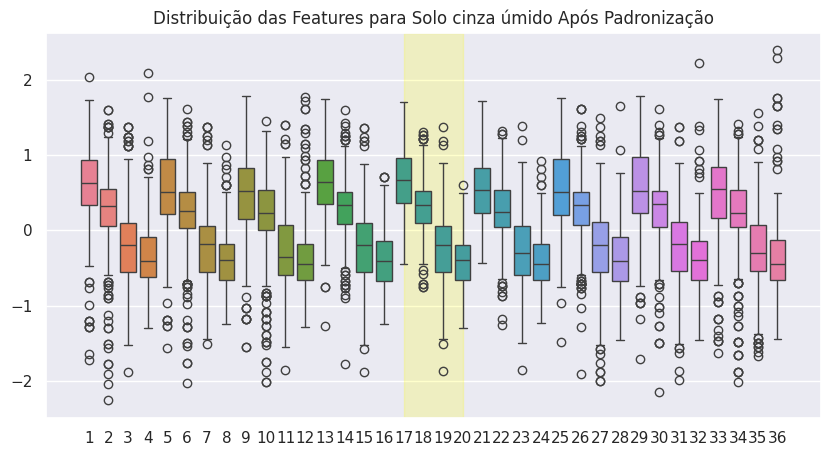

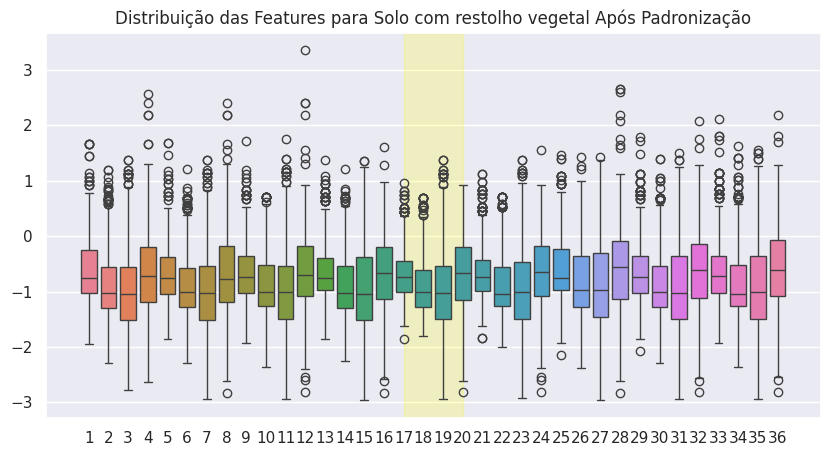

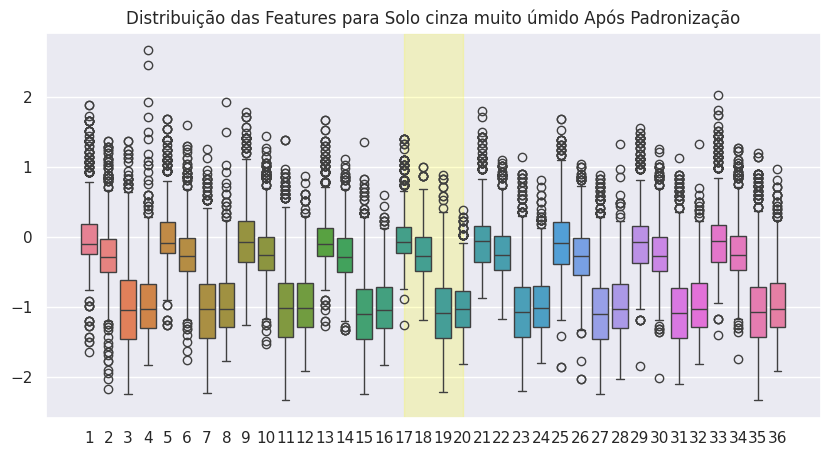

In [97]:
def box_plot_(xy, scaled = False):
    classes = np.unique(xy['class'])
    for classe in classes:
        Xc = xy[xy['class'] == classe].loc[:, xy.columns != 'class']  # dados da classe
        class_ = getClass(classe)
        class_name = class_['class_name'][0]
        class_color = class_['color'][0]

        standard_ = " Após Padronização" if scaled else ""

        plt.figure(figsize=(10,5))
        seaborn.boxplot(data=Xc)  # banda do pixel central
        plt.title(f"Distribuição das Features para {class_name}{standard_}")
        plt.axvspan(16, 19, color='yellow', alpha=0.2, label='Pixel central')
        plt.show()

box_plot_(xy)
box_plot_(xy_scaled, True)

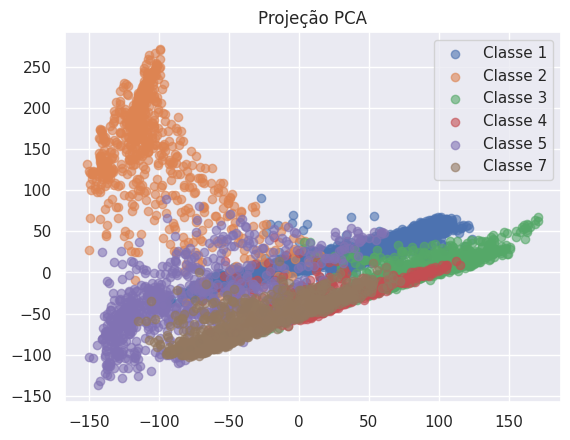

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

y_ = y.to_numpy().ravel()

plt.figure()
for c in np.unique(y):
    plt.scatter(X_pca[y_ == c, 0],
                X_pca[y_ == c, 1],
                label=f"Classe {c}",
                alpha=0.6)

plt.legend()
plt.title("Projeção PCA")
plt.show()

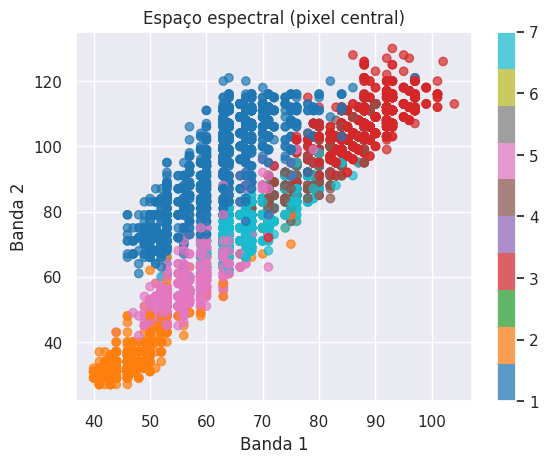

In [49]:
central_pixels = X.iloc[:, 16:20].to_numpy()

plt.figure()
plt.scatter(central_pixels[:, 0],
            central_pixels[:, 1],
            c=y_,
            cmap='tab10',
            alpha=0.7)

plt.xlabel("Banda 1")
plt.ylabel("Banda 2")
plt.title("Espaço espectral (pixel central)")
plt.colorbar()
plt.show()

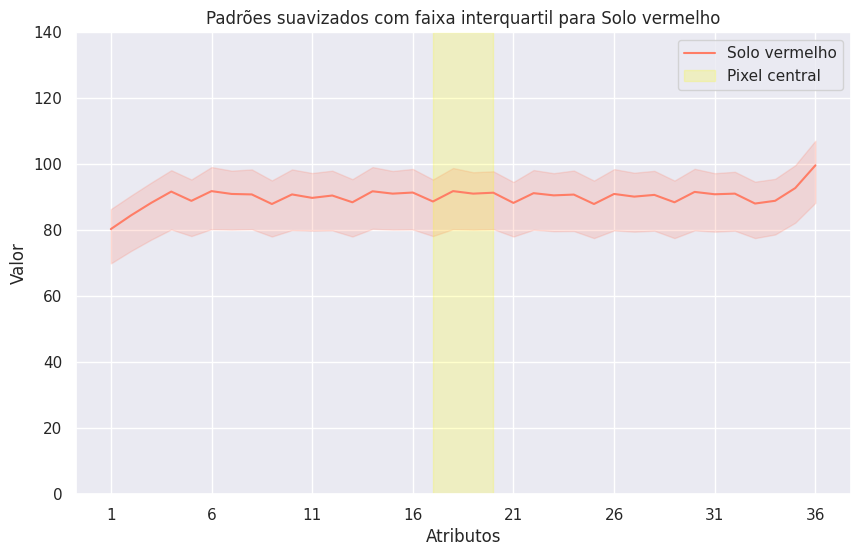

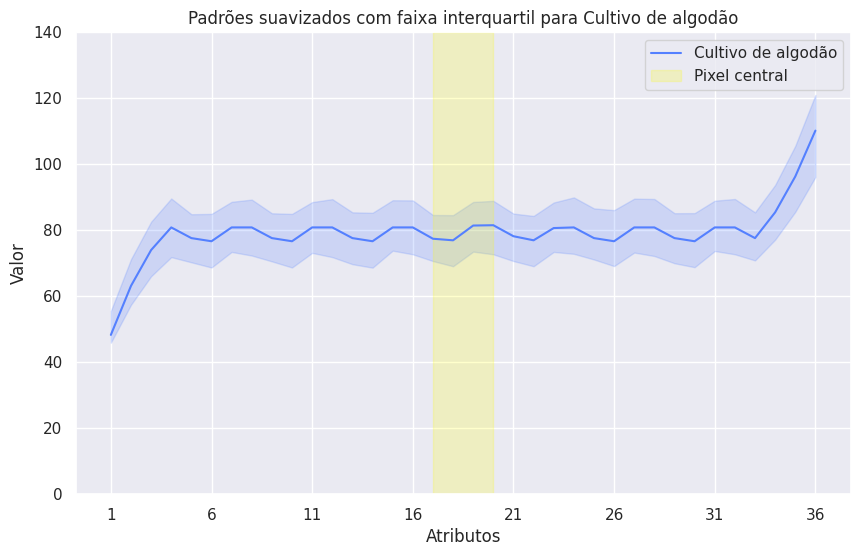

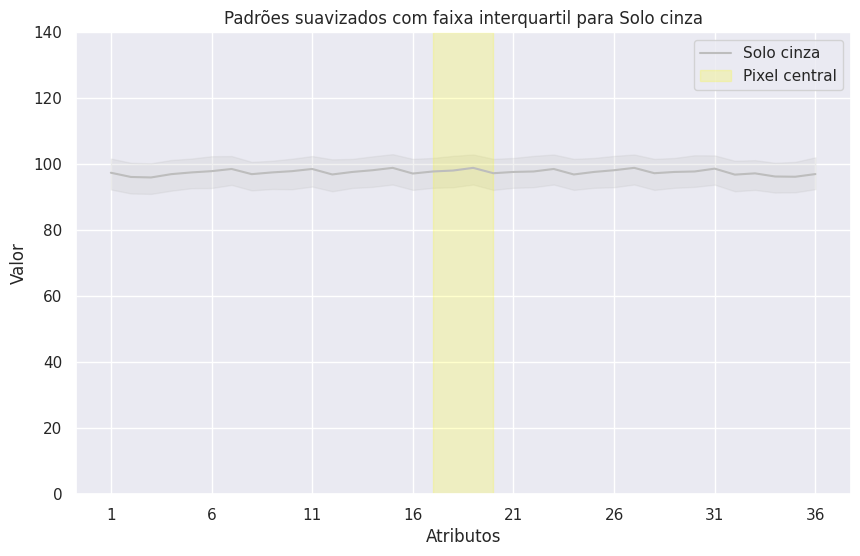

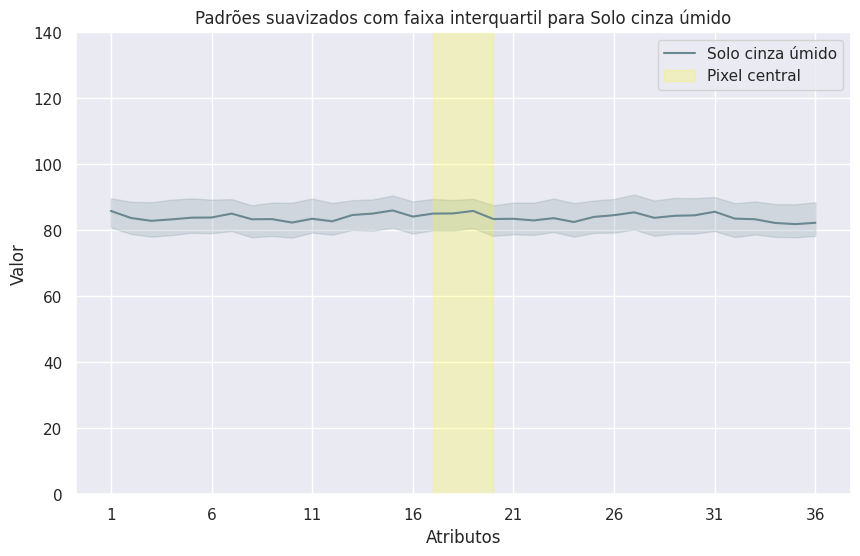

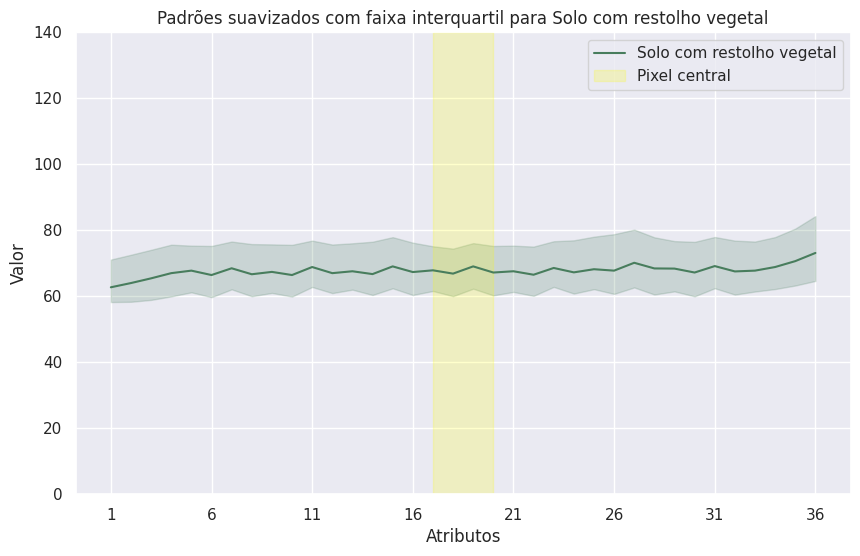

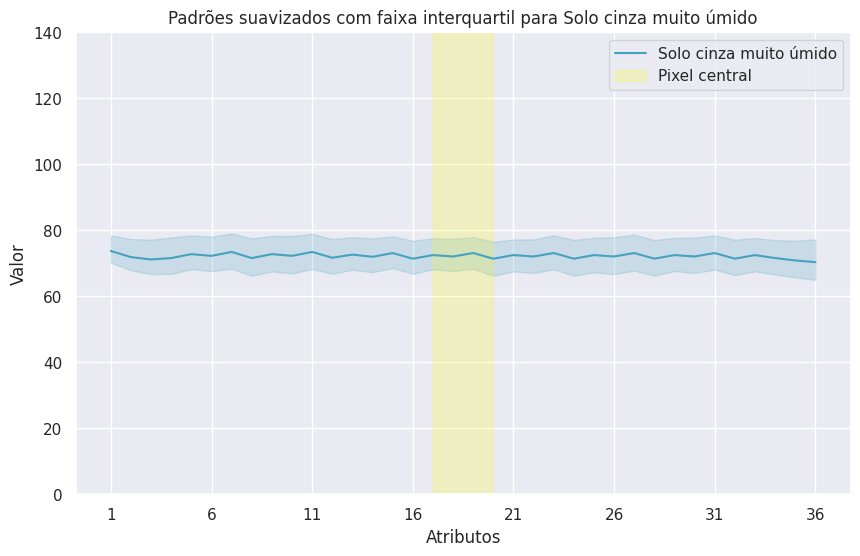

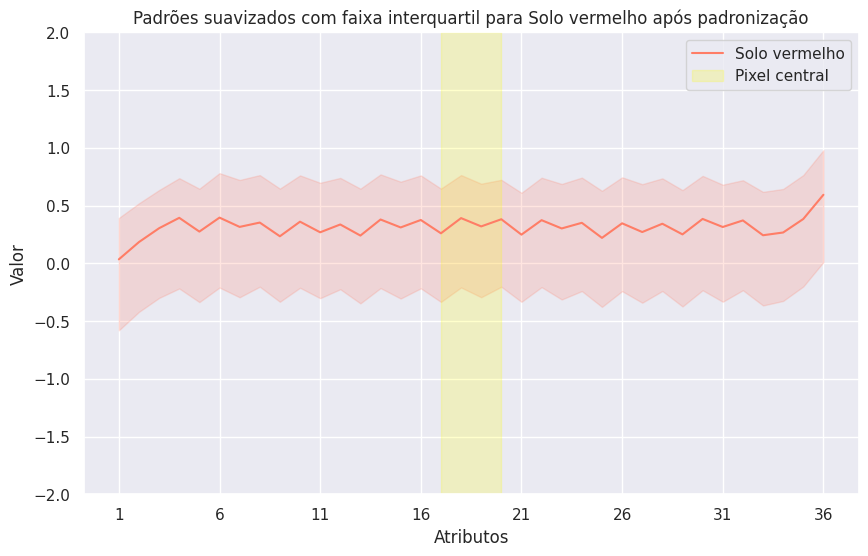

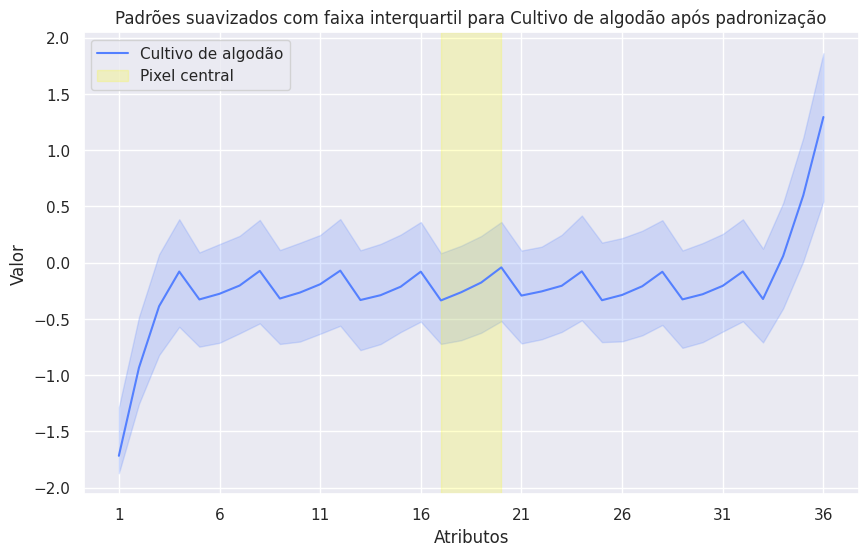

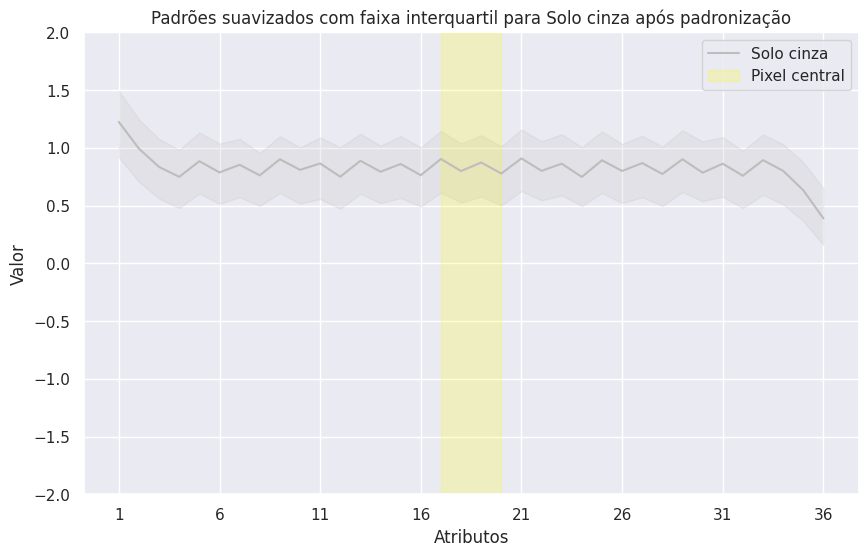

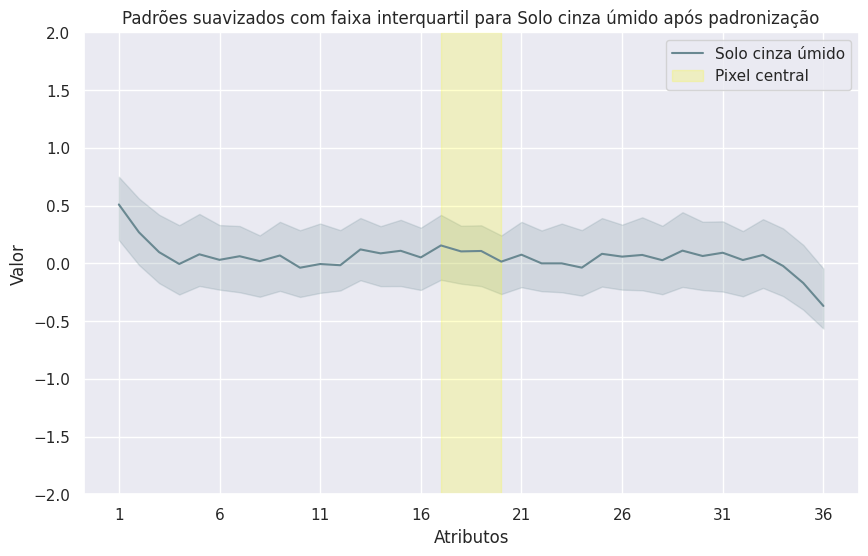

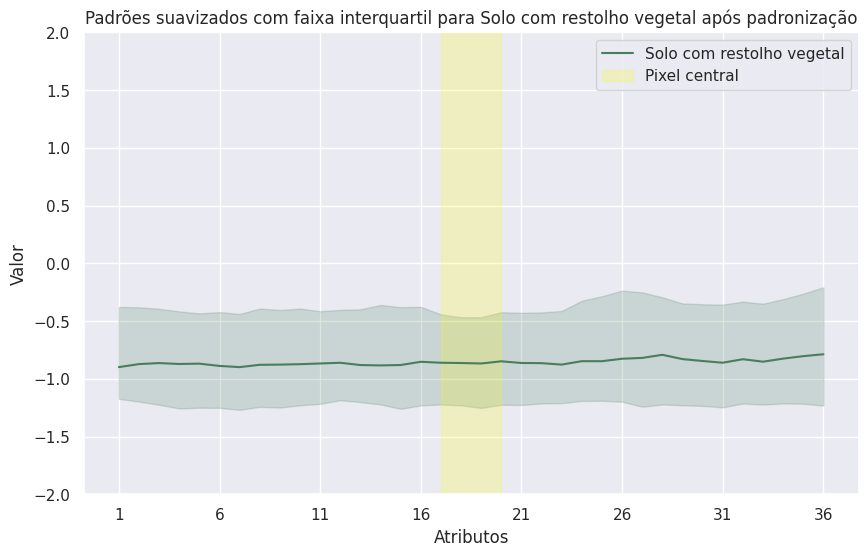

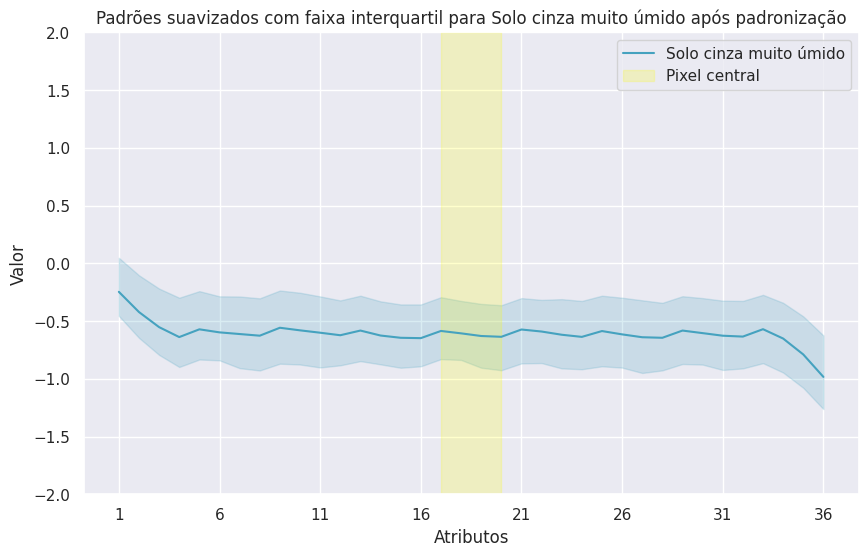

In [78]:
def plot_patterns_sep(xy, scaled = False):
    classes = np.unique(xy['class'])
    for classe in classes:
        Xc = xy[xy['class'] == classe].loc[:, xy.columns != 'class']  # dados da classe
        class_ = getClass(classe)
        class_name = class_['class_name'][0]
        class_color = class_['color'][0]

        standard_ = " após padronização" if scaled else ""
        
        # Quartis
        q1 = np.percentile(Xc, 25, axis=0)
        med = np.percentile(Xc, 50, axis=0)
        q3 = np.percentile(Xc, 75, axis=0)
        
        # --- Suavização ---
        # janela precisa ser ímpar e <= número de features
        window = min(7, len(med) if len(med)%2==1 else len(med)-1)
        
        q1_s = savgol_filter(q1, window_length=window, polyorder=2)
        med_s = savgol_filter(med, window_length=window, polyorder=2)
        q3_s = savgol_filter(q3, window_length=window, polyorder=2)
        
        x_axis = np.arange(1, (len(med_s) + 1))
    
        plt.figure(figsize=(10,6))
        
        # Linha da mediana
        plt.plot(x_axis, med_s, label=class_name, color = class_color)
        
        # Faixa interquartil
        plt.fill_between(x_axis, q1_s, q3_s, alpha=0.2, color = class_color)

        plt.axvspan(17, 20, color='yellow', alpha=0.2, label='Pixel central')
    
        plt.xlabel("Atributos")
        plt.ylabel("Valor")
        plt.title(f"Padrões suavizados com faixa interquartil para {class_name}{standard_}")
        if scaled:
            plt.yticks(np.arange(-2, 2.5, 0.5))            
        else:
            plt.yticks(np.arange(0, 150, 20))
        plt.xticks(np.arange(1, 37, step=5)) 
        plt.legend()
        plt.show()
    
plot_patterns_sep(xy)
plot_patterns_sep(xy_scaled, True)

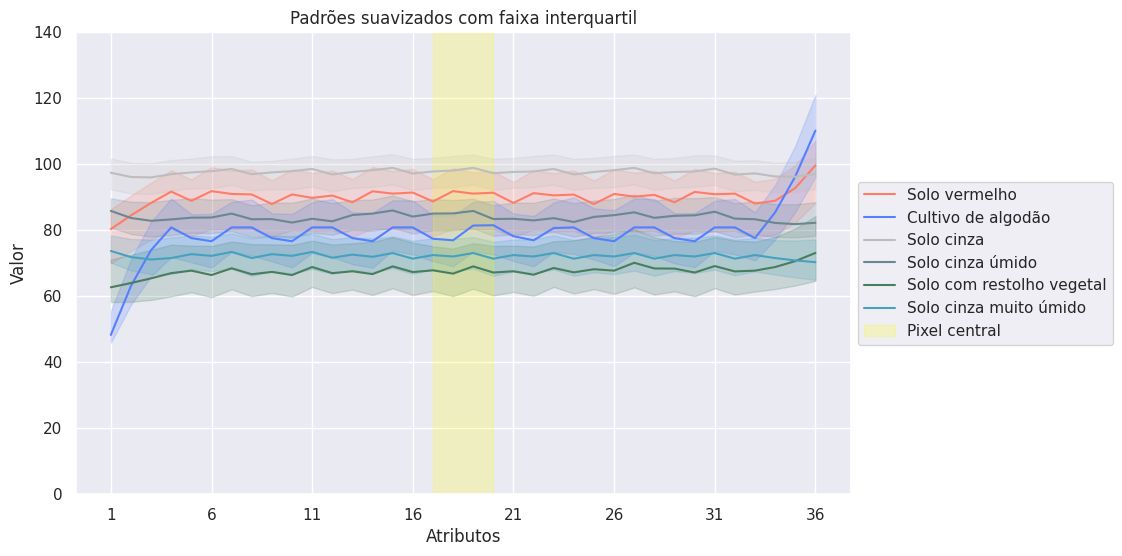

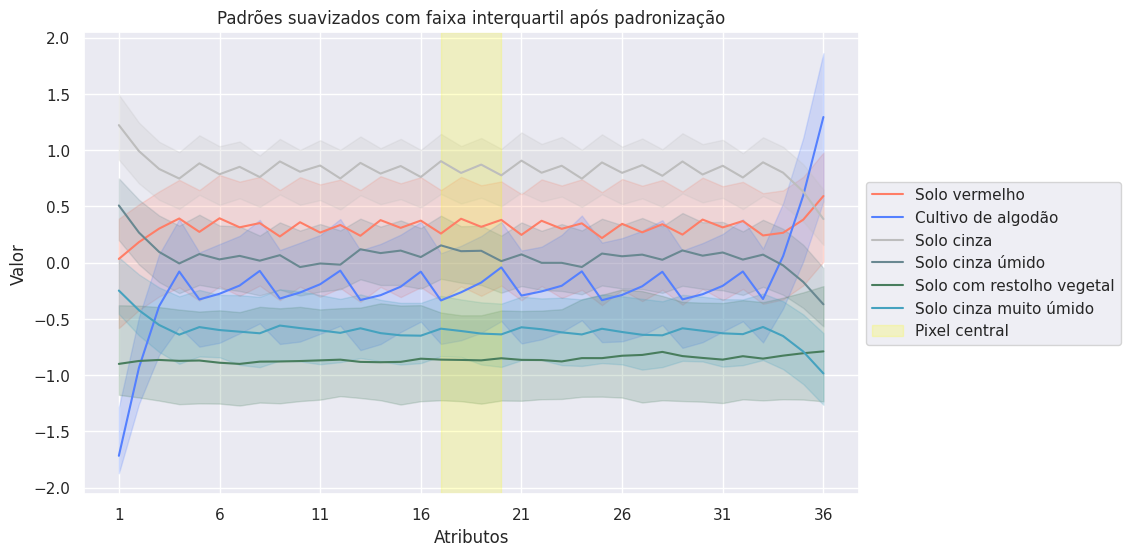

In [81]:
def plot_patterns(xy, scaled = False):
    classes = np.unique(xy['class'])
    
    plt.figure(figsize=(10,6))
    
    for classe in classes:
        Xc = xy[xy['class'] == classe].loc[:, xy.columns != 'class']  # dados da classe
        class_ = getClass(classe)
        class_name = class_['class_name'][0]
        class_color = class_['color'][0]

        standard_ = " após padronização" if scaled else ""
        
        # Quartis
        q1 = np.percentile(Xc, 25, axis=0)
        med = np.percentile(Xc, 50, axis=0)
        q3 = np.percentile(Xc, 75, axis=0)
        
        # --- Suavização ---
        # janela precisa ser ímpar e <= número de features
        window = min(7, len(med) if len(med)%2==1 else len(med)-1)
        
        q1_s = savgol_filter(q1, window_length=window, polyorder=2)
        med_s = savgol_filter(med, window_length=window, polyorder=2)
        q3_s = savgol_filter(q3, window_length=window, polyorder=2)
        
        x_axis = np.arange(1, (len(med_s) + 1))
        
        # Linha da mediana
        plt.plot(x_axis, med_s, label=class_name, color = class_color)
        
        # Faixa interquartil
        plt.fill_between(x_axis, q1_s, q3_s, alpha=0.2, color = class_color)

    plt.axvspan(17, 20, color='yellow', alpha=0.2, label='Pixel central')    
    plt.xlabel("Atributos")
    plt.ylabel("Valor")
    plt.title(f"Padrões suavizados com faixa interquartil{standard_}")
    if scaled:
        plt.yticks(np.arange(-2, 2.5, 0.5))            
    else:
        plt.yticks(np.arange(0, 150, 20))
    plt.xticks(np.arange(1, 37, step=5)) 
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

plot_patterns(xy)
plot_patterns(xy_scaled, True)

## Transformação do problema em binário

In [65]:
def getAllClassesBinary():
    return pd.DataFrame({
        "class_name": ["Solo vermelho", "Não é solo vermelho"],
        "index": [1, 0],
        "color": ["#FF7D66", "#AB5B96"]
    })

def getClassBinary(index):
    classes = getAllClassesBinary()
    result = classes[index == classes["index"]]
    result = result.reset_index(drop = True)
    return result

getAllClassesBinary()

,class_name,index,color
0,Solo vermelho,1,#FF7D66
1,Não é solo vermelho,0,#AB5B96


In [66]:
xy_binary = xy.copy()
xy_binary.loc[xy['class'] != 1, 'class'] = 0
xy_binary[:5]

,class,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,0,92,115,120,94,84,102,106,79,84,...,134,104,88,121,128,100,84,107,113,87
1,0,84,102,106,79,84,102,102,83,80,...,128,100,84,107,113,87,84,99,104,79
2,0,84,102,102,83,80,102,102,79,84,...,113,87,84,99,104,79,84,99,104,79
3,0,80,102,102,79,84,94,102,79,80,...,104,79,84,99,104,79,84,103,104,79
4,0,84,94,102,79,80,94,98,76,80,...,104,79,84,103,104,79,79,107,109,87


In [95]:
xy_binary_scaled = xy_scaled.copy()
xy_binary_scaled.loc[xy['class'] != 1, 'class'] = 0
xy_binary_scaled[:5]

,class,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,0,1.661177,1.372574,1.244208,0.603682,1.095101,0.819608,0.413457,-0.184648,1.120130,...,2.094080,1.123729,1.412427,1.656979,1.729516,0.912814,1.139685,1.058116,0.843046,0.235904
1,0,1.073150,0.804404,0.403097,-0.190128,1.095101,0.819608,0.173402,0.026552,0.823164,...,1.732879,0.913090,1.115947,1.044165,0.831474,0.230119,1.139685,0.707472,0.303936,-0.183981
2,0,1.073150,0.804404,0.162779,0.021555,0.800119,0.819608,0.173402,-0.184648,1.120130,...,0.829875,0.228512,1.115947,0.693985,0.292649,-0.190001,1.139685,0.707472,0.303936,-0.183981
3,0,0.779136,0.804404,0.162779,-0.190128,1.095101,0.470029,0.173402,-0.184648,0.823164,...,0.288073,-0.192767,1.115947,0.693985,0.292649,-0.190001,1.139685,0.882794,0.303936,-0.183981
4,0,1.073150,0.454761,0.162779,-0.190128,0.800119,0.470029,-0.066654,-0.343047,0.823164,...,0.288073,-0.192767,1.115947,0.869075,0.292649,-0.190001,0.766566,1.058116,0.603442,0.235904


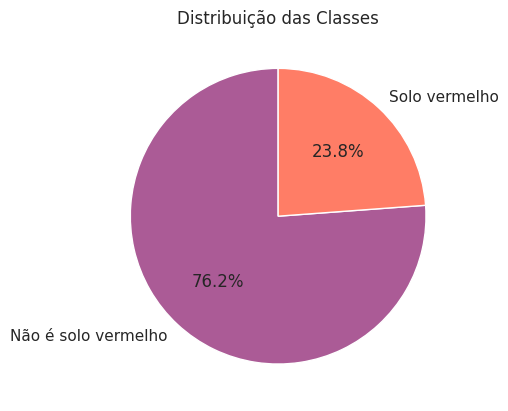

In [69]:
# Contar amostras por classe
class_counts = pd.Series(list(xy_binary['class'])).value_counts().sort_index()

# Labels (nomes das classes)
labels = [ str(getClassBinary(index)['class_name'][0]) for index in list(set(xy_binary['class'])) ]

colors = [ str(getClassBinary(index)['color'][0]) for index in list(set(xy_binary['class'])) ]

# Plotar gráfico de pizza
plt.figure()
plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição das Classes')

plt.show()

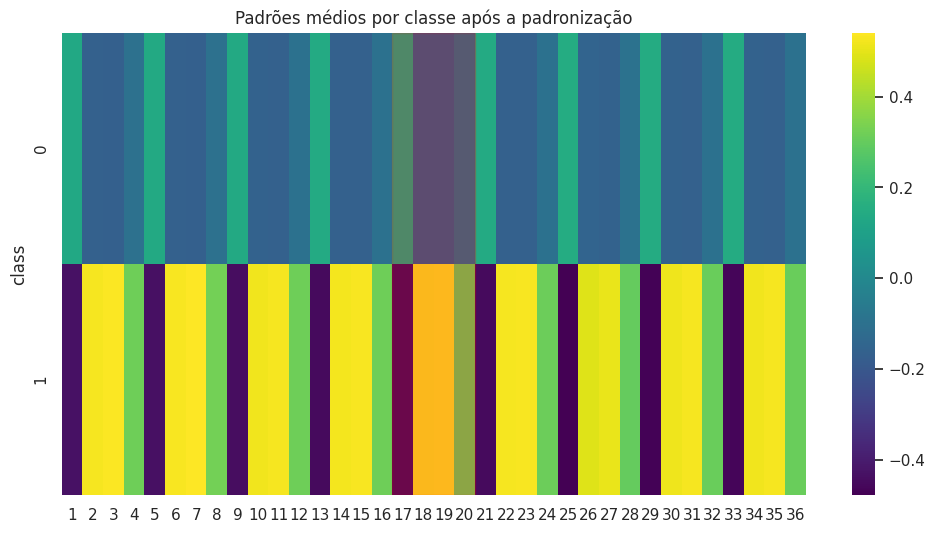

In [91]:
padroes = xy_binary_scaled.groupby('class').mean()

plt.figure(figsize=(12,6))
seaborn.heatmap(padroes, cmap='viridis')
plt.title("Padrões médios por classe após a padronização")
plt.axvspan(16, 20, color='red', alpha=0.2, label='Pixel central')
plt.show()

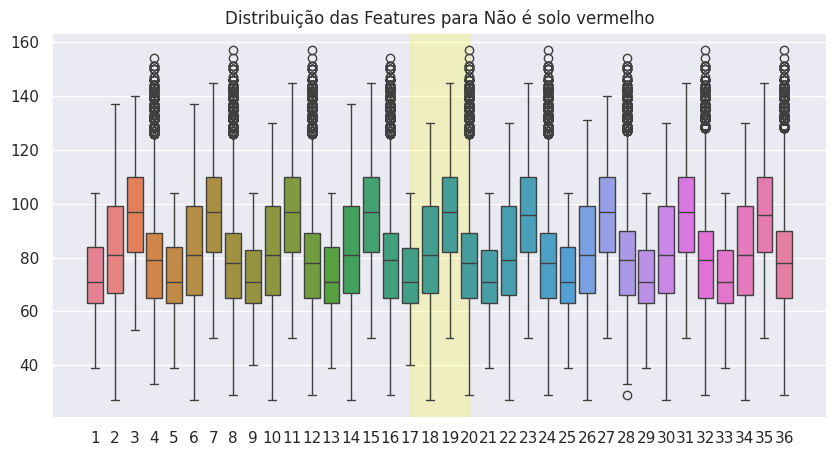

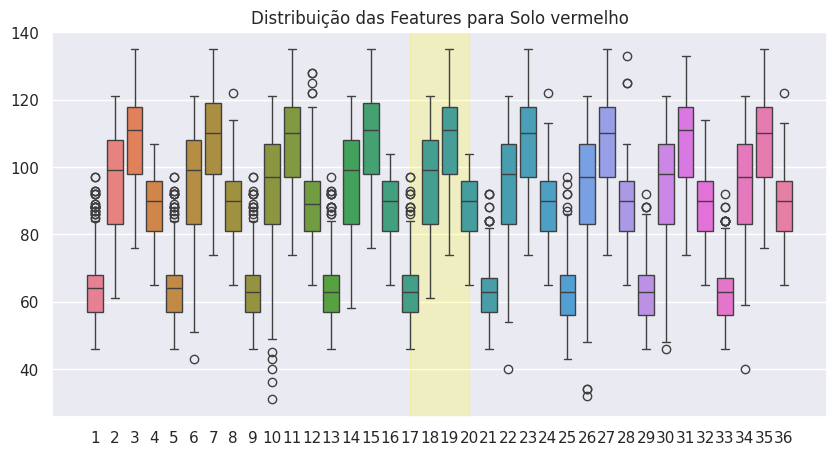

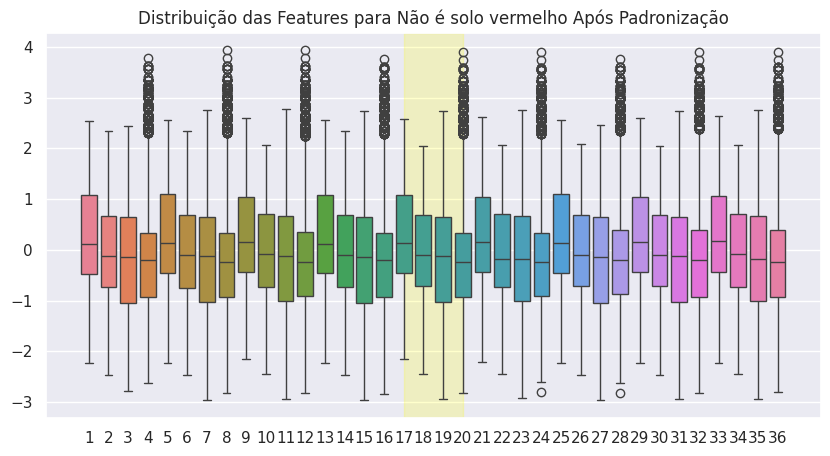

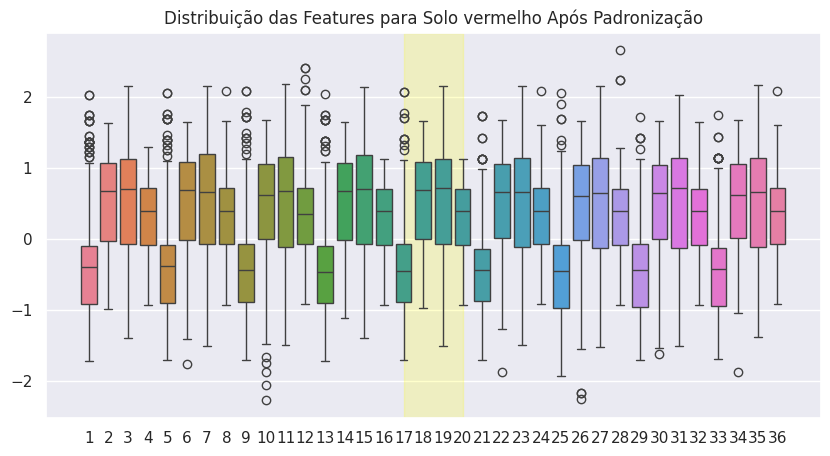

In [98]:
def box_plot_(xy, scaled = False):
    classes = np.unique(xy['class'])
    for classe in classes:
        Xc = xy[xy['class'] == classe].loc[:, xy.columns != 'class']  # dados da classe
        class_ = getClassBinary(classe)
        class_name = class_['class_name'][0]
        class_color = class_['color'][0]

        standard_ = " Após Padronização" if scaled else ""

        plt.figure(figsize=(10,5))
        seaborn.boxplot(data=Xc)  # banda do pixel central
        plt.title(f"Distribuição das Features para {class_name}{standard_}")
        plt.axvspan(16, 19, color='yellow', alpha=0.2, label='Pixel central')
        plt.show()

box_plot_(xy_binary)
box_plot_(xy_binary_scaled, True)

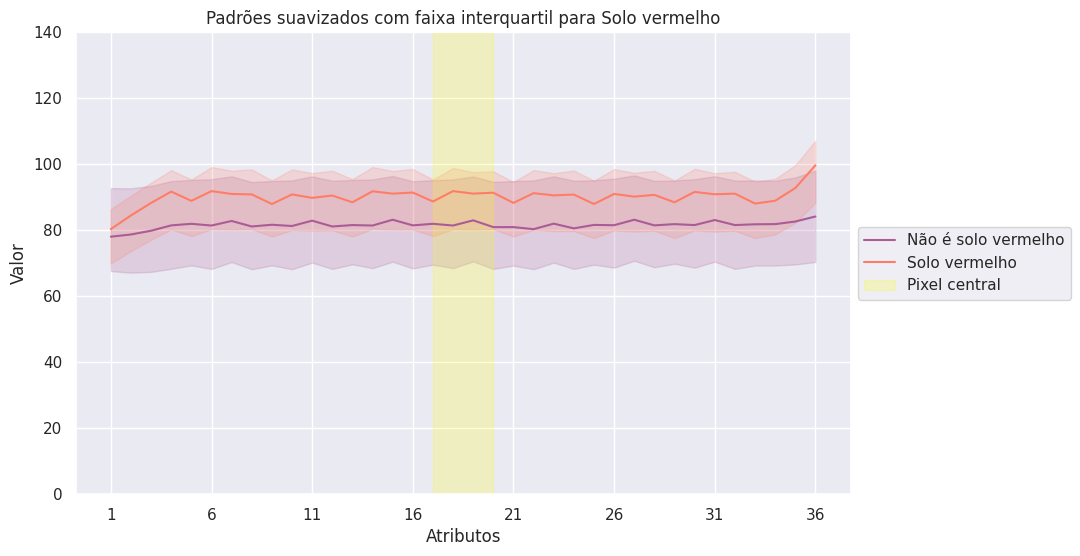

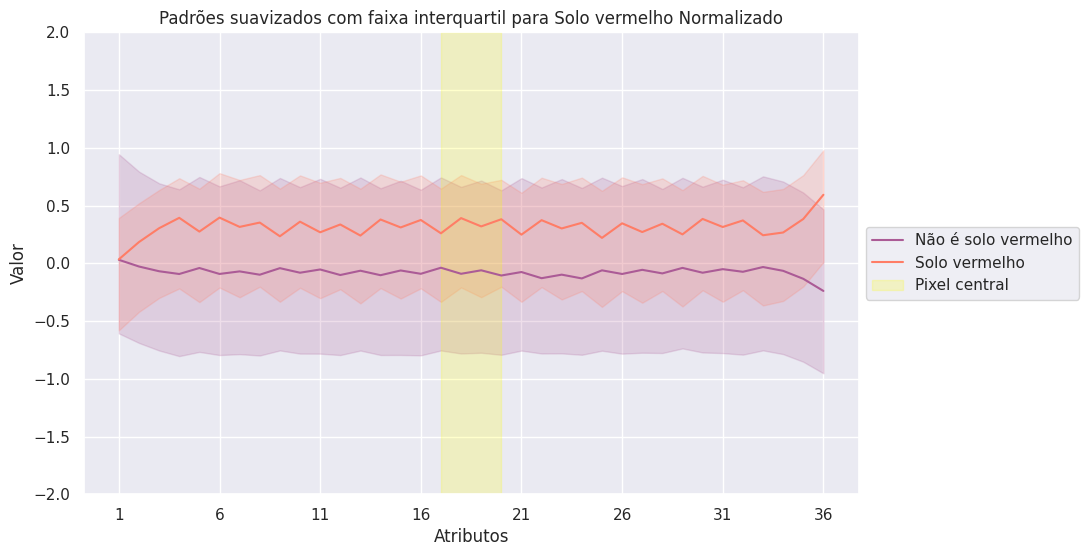

In [99]:
def plot_patterns(xy, normalized = False):
    classes = np.unique(xy['class'])
    
    plt.figure(figsize=(10,6))
    
    for classe in classes:
        Xc = xy[xy['class'] == classe].loc[:, xy.columns != 'class']  # dados da classe
        class_ = getClassBinary(classe)
        class_name = class_['class_name'][0]
        class_color = class_['color'][0]

        normalized_ = " Normalizado" if normalized else ""
        
        # Quartis
        q1 = np.percentile(Xc, 25, axis=0)
        med = np.percentile(Xc, 50, axis=0)
        q3 = np.percentile(Xc, 75, axis=0)
        
        # --- Suavização ---
        # janela precisa ser ímpar e <= número de features
        window = min(7, len(med) if len(med)%2==1 else len(med)-1)
        
        q1_s = savgol_filter(q1, window_length=window, polyorder=2)
        med_s = savgol_filter(med, window_length=window, polyorder=2)
        q3_s = savgol_filter(q3, window_length=window, polyorder=2)
        
        x_axis = np.arange(1, (len(med_s) + 1))
        
        # Linha da mediana
        plt.plot(x_axis, med_s, label=class_name, color = class_color)
        
        # Faixa interquartil
        plt.fill_between(x_axis, q1_s, q3_s, alpha=0.2, color = class_color)

    plt.axvspan(17, 20, color='yellow', alpha=0.2, label='Pixel central')    
    plt.xlabel("Atributos")
    plt.ylabel("Valor")
    plt.title(f"Padrões suavizados com faixa interquartil para {class_name}{normalized_}")
    if normalized:
        plt.yticks(np.arange(-2, 2.5, 0.5))            
    else:
        plt.yticks(np.arange(0, 150, 20))
    plt.xticks(np.arange(1, 37, step=5)) 
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
    
plot_patterns(xy_binary)
plot_patterns(xy_binary_scaled, True)

## Definição do Modelo:

### Definição da arquitetura MLP

Usa-se ReLU nas camadas ocultas porque ela evita saturação de gradiente (como acontece com sigmoid/tanh), tornando o treinamento mais estável e rápido, além de induzir esparsidade (muitos neurônios ficam zerados), o que ajuda na generalização.

ReLU

$$f(x) = \begin{cases} 0 & \text{para } x < 0 \\ x & \text{para } x \geq 0 \end{cases}$$

Na camada de saída, usa-se sigmoid porque ela comprime o resultado para o intervalo [0,1], permitindo interpretar a saída como probabilidade de pertencer à classe positiva (por exemplo, desmatamento), o que funciona naturalmente com um limiar como 0.5 para decisão binária.

Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

In [249]:
def relu(x):
    return np.maximum(0, x)

def d_relu(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x)**2

def recover_my_MLP():
    seed = 42
    topology = [36, 24, 12, 1]
    layers = [
        Layer(24, Neuron, relu, d_relu),
        Layer(12, Neuron, relu, d_relu),
        Layer(1, Neuron, sigmoid, d_sigmoid)
    ]
    return FFNeuralNetwork(topology, layers, rand_seed = seed)

# Este aqui é mais robusto
def recover_my_MLP_alt():
    seed = 42
    topology = [36, 64, 32, 1]
    layers = [
        Layer(64, Neuron, relu, d_relu),
        Layer(32, Neuron, tanh, d_tanh),
        Layer(1, Neuron, sigmoid, d_sigmoid)
    ]
    return FFNeuralNetwork(topology, layers, rand_seed = seed)

## Tradicional _Holdout_:

### Recuperação dosdos e padronização:

In [235]:
# Carregar o conjunto de treino
train_data = pd.read_csv('./landsat_data/sat.trn', header=None, sep=' ')
y_holdout = np.array(train_data[36])
y_holdout = np.where(y_holdout != 1, 0, y_holdout)
X_holdout = np.array(train_data.loc[:, train_data.columns != 36])

X_holdout, X_holdout_val, y_holdout, y_holdout_val = train_test_split(
    X_holdout, y_holdout, test_size=0.2, stratify=y_holdout, random_state=42
)

# Carregar o conjunto de teste
test_data = pd.read_csv('./landsat_data/sat.tst', header=None, sep=' ')
y_holdout_test = np.array(test_data[36])
y_holdout_test = np.where(y_holdout_test != 1, 0, y_holdout_test)
X_holdout_test = np.array(test_data.loc[:, train_data.columns != 36])

scaler = StandardScaler()
X_holdout = scaler.fit_transform(X_holdout)
X_holdout_val = scaler.transform(X_holdout_val)
X_holdout_test = scaler.transform(X_holdout_test)

print(f"Formato do treino: {X_holdout.shape}")
print(f"Formato da validação: {X_holdout_val.shape}")
print(f"Formato do teste: {X_holdout_test.shape}")

Formato do treino: (3548, 36)
Formato da validação: (887, 36)
Formato do teste: (2000, 36)


### Treinamento:

In [252]:
nn_holdout = recover_my_MLP_alt()
nn_holdout.fit_with_val(X_holdout, y_holdout, X_holdout_val, y_holdout_val, learning_rate=0.01, n_epochs=100)

Epoch 0 | Train MSE: 0.0523 | Val MSE: 0.0284
Epoch 50 | Train MSE: 0.0044 | Val MSE: 0.0172


### Validação e test:

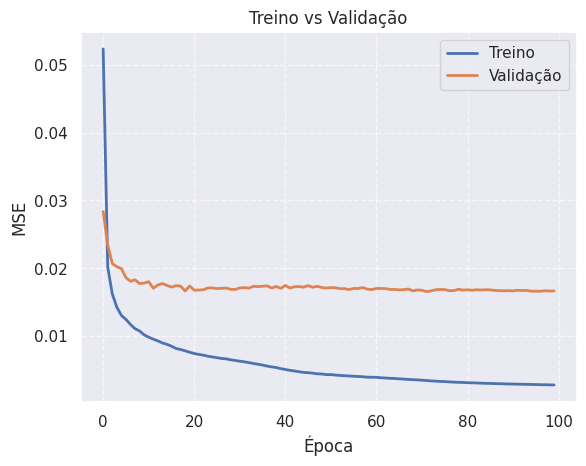


=== Avaliação no conjunto externo ===
Acurácia: 0.9885
Precisão: 0.9782
Recall: 0.9718
F1-score: 0.9750


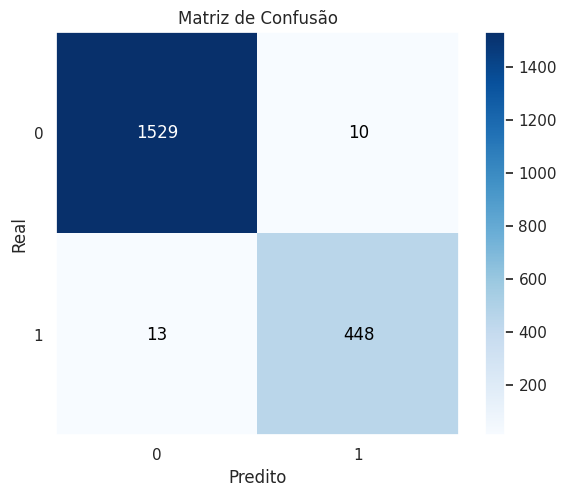

In [253]:
nn_holdout.plot_train_val_mse()
results_test = nn_holdout.test(X_holdout_test, y_holdout_test, threshold=0.5, scaled = True)
nn_holdout.plot_confusion_matrix(y_holdout_test, results_test['y_pred'])

In [258]:
nn_holdout = recover_my_MLP()
nn_holdout.fit_with_val(X_holdout, y_holdout, X_holdout_val, y_holdout_val, learning_rate=0.002, n_epochs=100)

Epoch 0 | Train MSE: 0.2817 | Val MSE: 0.2471
Epoch 50 | Train MSE: 0.0137 | Val MSE: 0.0163


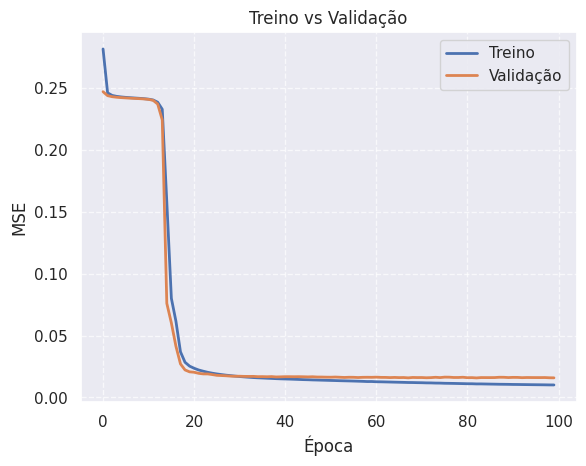


=== Avaliação no conjunto externo ===
Acurácia: 0.9820
Precisão: 0.9610
Recall: 0.9610
F1-score: 0.9610


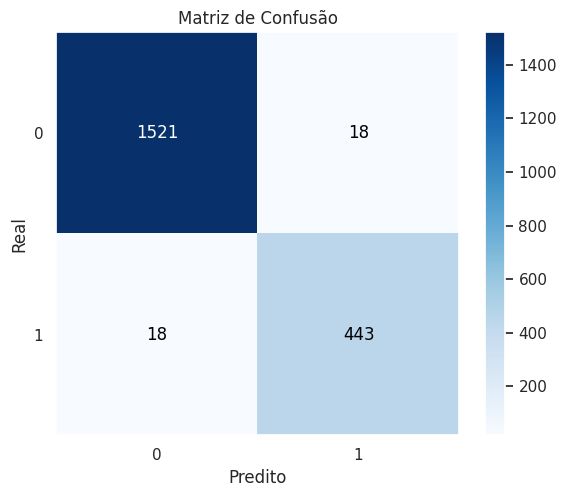

In [259]:
nn_holdout.plot_train_val_mse()
results_test = nn_holdout.test(X_holdout_test, y_holdout_test, threshold=0.5, scaled = True)
nn_holdout.plot_confusion_matrix(y_holdout_test, results_test['y_pred'])

## Validação Cruzada _Cross Validation_:

### Separação dos dados

Separação em treinamento e teste usando a proporção 70% e 30%, respectivamente para treinamento e teste.

In [260]:
X = np.array(xy_binary.loc[:, xy_binary.columns != 'class'])
y = np.array(xy_binary.loc[:, xy_binary.columns == 'class']['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print("Total", len(y), "amostras")
print("Treino", len(y_train), "amostras")
print("Teste", len(y_test), "amostras")

colors = {}
for i in np.unique(y):
    colors[int(i)] = getClassBinary(i)['color'][0]
colors

Total 6435 amostras
Treino 4504 amostras
Teste 1931 amostras


{0: '#AB5B96', 1: '#FF7D66'}

### Separação dos folds

Usar a abordagem estratificada pois o problema é desbalanceado.

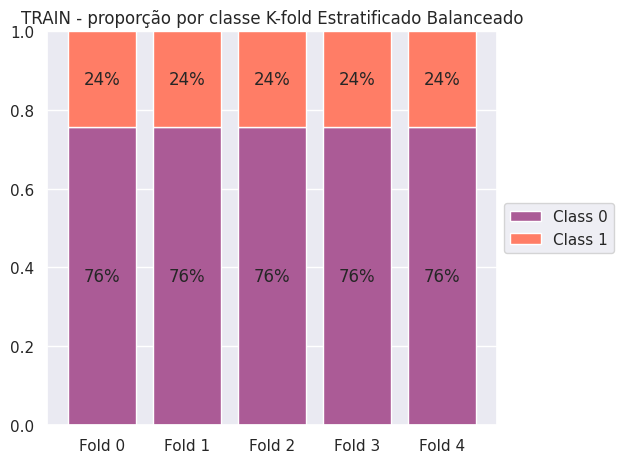

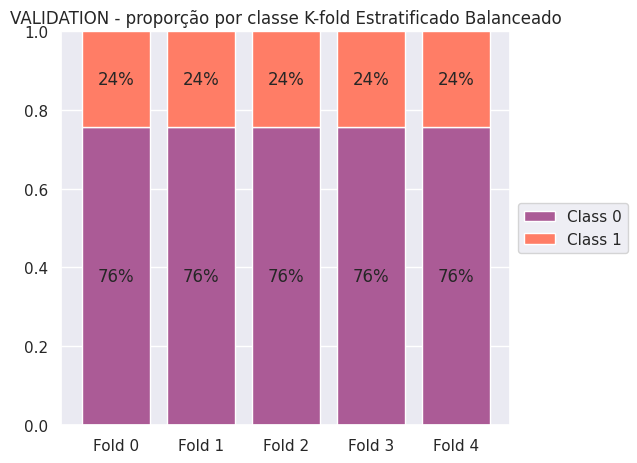

In [261]:
kfold = Kfold()

stratified_folds = kfold.get_stratified_folds(X_train, y_train)

kfold.plot_folds_distribution(stratified_folds, "K-fold Estratificado Balanceado", colors)

### Treinamento

In [265]:
nn_stratified = recover_my_MLP()
nn_stratified.fit_by_folds(stratified_folds, learning_rate=0.001, n_epochs=100, threshold = 0.5)


=== Fold 0 ===
Epoch 0 | Train MSE: 0.2998 | Val MSE: 0.2601
Epoch 50 | Train MSE: 0.0155 | Val MSE: 0.0192
Erro médio (val): 0.0251
MSE (val): 0.0164
Acurácia (val): 0.9811
Precisão (val): 0.9631
Recall (val): 0.9587
F1-score (val): 0.9609

=== Fold 1 ===
Epoch 0 | Train MSE: 0.3041 | Val MSE: 0.2597
Epoch 50 | Train MSE: 0.0147 | Val MSE: 0.0180
Erro médio (val): 0.0215
MSE (val): 0.0163
Acurácia (val): 0.9811
Precisão (val): 0.9548
Recall (val): 0.9679
F1-score (val): 0.9613

=== Fold 2 ===
Epoch 0 | Train MSE: 0.3053 | Val MSE: 0.2576
Epoch 50 | Train MSE: 0.0193 | Val MSE: 0.0241
Erro médio (val): 0.0251
MSE (val): 0.0172
Acurácia (val): 0.9811
Precisão (val): 0.9631
Recall (val): 0.9587
F1-score (val): 0.9609

=== Fold 3 ===
Epoch 0 | Train MSE: 0.3010 | Val MSE: 0.2634
Epoch 50 | Train MSE: 0.0179 | Val MSE: 0.0213
Erro médio (val): 0.0253
MSE (val): 0.0161
Acurácia (val): 0.9811
Precisão (val): 0.9589
Recall (val): 0.9633
F1-score (val): 0.9611

=== Fold 4 ===
Epoch 0 | Train 

### Validação e Teste

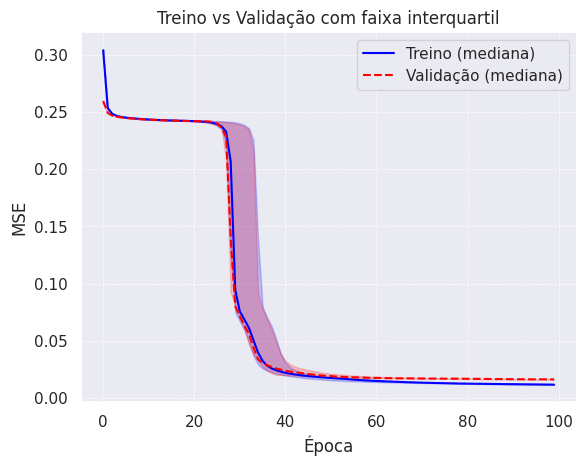

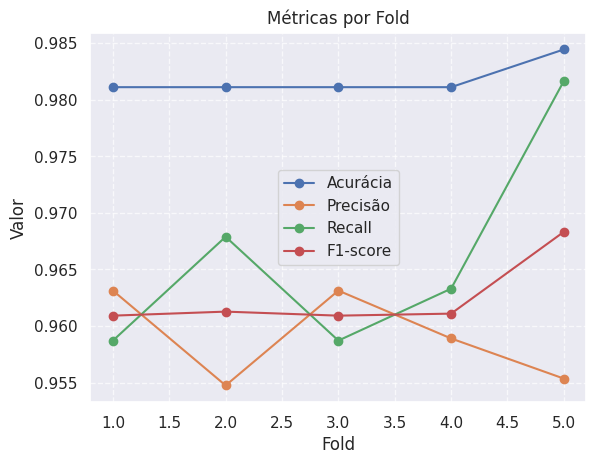


=== Avaliação no conjunto externo ===
Acurácia: 0.9803
Precisão: 0.9508
Recall: 0.9637
F1-score: 0.9572


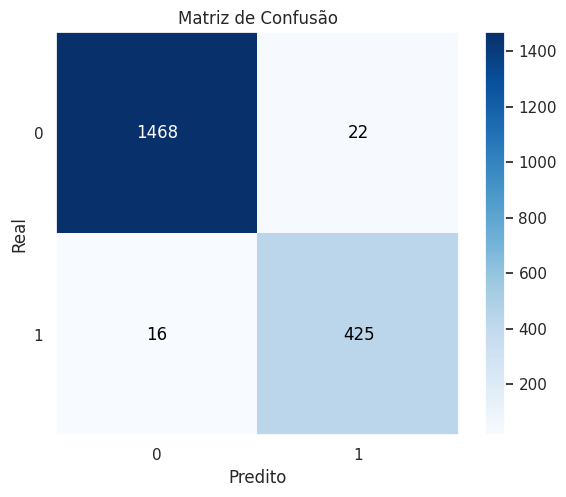

In [267]:
nn_stratified.plot_train_val_quartis()
nn_stratified.plot_metrics_by_folds()
results_test = nn_stratified.test(X_test, y_test)
nn_stratified.plot_confusion_matrix(y_test, results_test['y_pred'])